# 📘 Support Vector Machines (SVM)

## 1. 🧭 Cas linéairement séparable

Un problème est dit **linéairement séparable** si on peut tracer une **droite (en 2D)** ou un **hyperplan (en dimensions supérieures)** qui sépare **parfaitement deux classes** sans erreur de classification.

---

### 🎯 **Objectif du SVM :**
> Trouver **l’hyperplan qui maximise la marge** entre les deux classes, c'est-à-dire la distance minimale entre l'hyperplan et les points de chaque classe.

---

### 📝 **Formule de l'hyperplan :**
L'hyperplan est défini par l'équation suivante :  
$$
w \cdot x + b = 0
$$  
- **$w$** : Vecteur normal à l'hyperplan  
- **$x$** : Vecteur d'entrée  
- **$b$** : Biais  

---

### 📏 **Marge de séparation :**  
La **marge** est la distance entre les **hyperplans supports** (ceux qui passent par les points les plus proches de la frontière) :  
$$
\text{Marge} = \frac{2}{\lVert w \rVert}
$$  
- Maximiser la marge revient à **minimiser $\lVert w \rVert$** sous contrainte que :  
  $$
  y_i (w \cdot x_i + b) \geq 1
  $$  
- Cela garantit que **tous les points sont correctement classés** et **en dehors de la marge**.  

---

### 💡 èle sur des **données inconnues**.  
- Plus la marge est large, plus le modèle est **robuste aux variations des données**.  





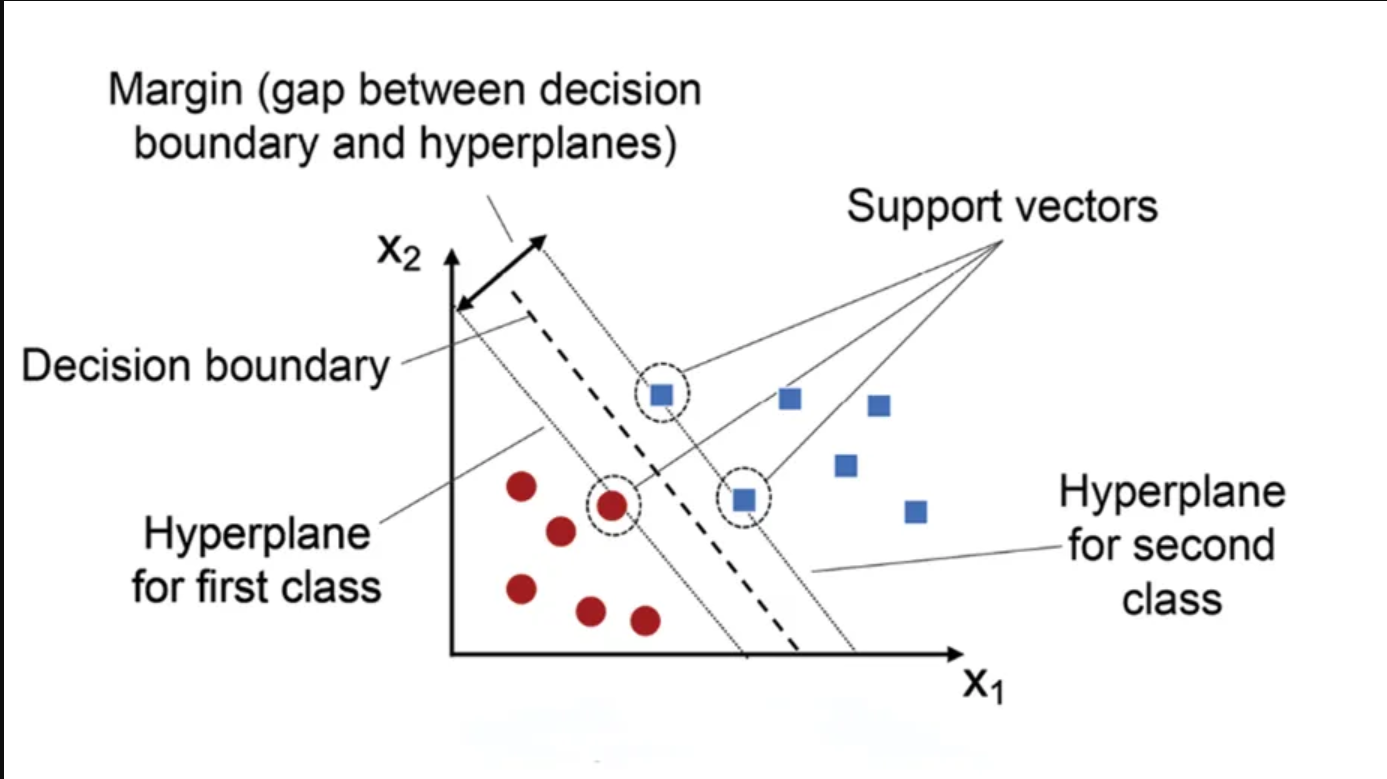

Dans les SVM (Support Vector Machines), nous avons deux hyperplans marginaux (un pour chaque classe) et une frontière de décision située au milieu.

La marge est la distance entre les deux hyperplans marginaux.

Les vecteurs de support sont situés exactement sur les hyperplans marginaux. Ils définissent la marge maximale car ils sont les plus proches de l'hyperplan central.

### 🔍 Pourquoi fixe-t-on la marge à ±1 dans le SVM ?

Dans un SVM linéaire, on cherche à séparer les deux classes à l’aide d’un hyperplan :

$$
\mathbf{w} \cdot \mathbf{x} + b = 0
$$

Mais en réalité, on veut **séparer avec une marge maximale**, ce qui impose que les points soient **au minimum à une certaine distance de l’hyperplan**. On introduit alors deux plans :

- $$ \mathbf{w} \cdot \mathbf{x} + b = +1 \quad \text{(marge pour la classe } +1) $$
- $$ \mathbf{w} \cdot \mathbf{x} + b = -1 \quad \text{(marge pour la classe } -1) $$

Les vecteurs de support sont ceux **exactement sur ces marges**. Ainsi, les contraintes deviennent :

$$
y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1
$$

---

### ⚠️ Pourquoi ±1 ? Est-ce obligatoire ?

**Non**, ce n’est pas une loi physique, c’est une **convention de normalisation**.

On **pourrait** écrire les contraintes comme :

$$
y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq c
$$

avec \( c > 0 \), mais cela ne change rien **géométriquement** :  
on obtiendrait **le même hyperplan** après avoir divisé \( \mathbf{w} \) et \( b \) par \( c \).

👉 En revanche, cela **changerait la marge** :

- Avec ±1, la marge est :  
  $$
  \frac{2}{\lVert \mathbf{w} \rVert}
  $$

- Avec ±c, elle serait :  
  $$
  \frac{2c}{\lVert \mathbf{w} \rVert}
  $$

Mais comme on peut **rescaler** les poids ensuite, on choisit par convention :

> 🎯 **Fixer la marge à ±1** pour :
> - Éviter l’ambiguïté d’échelle (sinon il y a une infinité de solutions),
> - Simplifier la contrainte \( y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 \),
> - Et faciliter la formulation du problème d’optimisation :
>   $$
>   \min_{\mathbf{w}, b} \frac{1}{2} \lVert \mathbf{w} \rVert^2
>   $$

---

### ✅ En résumé

- Fixer la marge à ±1 est **une normalisation utile**, pas une obligation.
- Cela permet au SVM de **trouver une solution unique et bien posée**.
- Si on choisissait une autre valeur (ex: ±2), il suffirait de **rescaler** les poids pour revenir à ±1.


## 🌟 Exemple : Calcul de la marge d'un SVM linéaire

### 📊 **Données :**
Supposons que nous ayons les points suivants appartenant à deux classes :  
- **Classe +1** : $(2, 3)$ et $(3, 5)$  
- **Classe -1** : $(1, 1)$ et $(2, 2)$  

---

### 🔧 **Hyperplan trouvé par le SVM :**
L'hyperplan obtenu après optimisation est :  
$$
w \cdot x + b = 0 \implies 2x_1 + 3x_2 - 7 = 0
$$  
- **$w = (2, 3)$**  
- **$b = -7$**  

---

### 📝 **Étape 1 : Calcul de la norme de $w$**  
Pour calculer la **marge**, nous avons besoin de la **norme du vecteur $w$** :  
$$
\lVert w \rVert = \sqrt{2^2 + 3^2} = \sqrt{4 + 9} = \sqrt{13} \approx 3.605
$$  

---

### 📝 **Étape 2 : Calcul de la marge**  
La formule de la **marge** est :  
$$
\text{Marge} = \frac{2}{\lVert w \rVert}
$$  
En remplaçant :  
$$
\text{Marge} = \frac{2}{3.605} \approx 0.554
$$  

---

### 💡 **Étape 3 : Vérification de la marge (distance d'un point à l'hyperplan)**  
Pour vérifier, calculons la **distance d'un point support** (par exemple $(2, 3)$) à l'hyperplan :  
$$
d = \frac{|w \cdot x + b|}{\lVert w \rVert}
$$  
En remplaçant :  
$$
d = 
\frac{|2 \cdot 2 + 3 \cdot 3 - 7|}{3.605}
$$  
$$
d = \frac{|4 + 9 - 7|}{3.605} = \frac{6}{3.605} \approx 0.554
$$  

---

### ✅ **Interprétation :**  
- La **marge calculée** est bien **0.554**, ce qui signifie que la **distance minimale entre l'hyperplan et les points de support** est de **0.554**.  
- Ce calcul montre que le **SVM a bien maximisé la marge** en plaçant les points de support **à égale distance de l'hyperplan**.  

---

### 📏 **Résumé des calculs :**  
- **Norme de $w$ :** $\sqrt{13} \approx 3.605$  
- **Marge :** $\frac{2}{3.605} \approx 0.554$  
- **Distance d'un point support :** $0.554$  
- La marge est **maximisée** lorsque les **points de support** sont **à égale distance de l'hyperplan**.  


## 2. ⚖️ Cas non parfaitement séparable – Slack variables

Lorsque les données ne sont **pas parfaitement séparables**, on introduit des **variables de relâchement** $ \xi_i $.  

### Nouvelle contrainte :
$$
y_i (w \cdot x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
$$

### Fonction objectif à minimiser :
$$
\frac{1}{2} \lVert w \rVert^2 + C \sum_i \xi_i
$$

- $ C $ est un **hyperparamètre** qui équilibre la **largeur de la marge** et le **nombre d'erreurs autorisées**.  
- $ \xi_i $ représente le **degré de violation** de la marge pour le point $ i $.  
- $ w $ est le **vecteur de poids** qui définit l'orientation de l'hyperplan.  
- $ b $ est le **biais** qui déplace l'hyperplan par rapport à l'origine.  
- $ y_i $ est la **classe** de l'exemple $ i $ ($ +1 $ ou $ -1 $).  
- $ x_i $ est le **vecteur de caractéristiques** de l'exemne **marge plus large**.  


![Description de l'image](svm_slack_variable.jpg)

### 📝 **Interprétation :**  
- Les **slack variables** $ \xi_i $ permettent aux points d'être **mal classés** ou **dans la marge** tout en introduisant une **pénalisation contrôlée** dans la fonction objectif.  
  - **Se trouvent à l'intérieur de la marge (mais du bon côté)** : Ces points sont **tolérés**, car ils ne franchissent pas l'hyperplan, mais ils **réduisent la marge maximale**.  
  - **Traversent l'hyperplan (mal classés, du mauvais côté)** : Ces points sont **pénalisés plus fortement** car ils se retrouvent **dans la classe opposée** à leur étiquette réelle.  

#### 🚩 **Différence de tolérance entre les deux cas :**

| Critère                               | Points dans la marge (bon côté)                | Points mal classés (mauvais côté)                 |
|---------------------------------------|-----------------------------------------------|--------------------------------------------------|
| **Position par rapport à l'hyperplan** | À l'intérieur de la marge mais du **bon côté**  | **Traversent l'hyperplan** (côté opposé)           |
| **Pénalisation**                      | **Moins pénalisés**                            | **Plus pénalisés**                                |
| **Impact sur la fonction objectif**    | **Moins d'impact** sur la perte                 | **Impact plus important** (coût plus élevé)        |
| **Explication**                       | Tolérés car ils restent dans leur classe, mais **réduisent la marge** | Non tolérés car **mal classés** (mauvaise prédiction) |

- Le **paramètre $ C $** contrôle le **compromis** entre une **marge large** et **moins d'erreurs**.  
- **Si $ C $ est grand**, le modèle **pénalise fortement les erreurs** et cherche une séparation stricte (moins de tolérance).  
- **Si $ C $ est petit**, le modèle **tolère plus d'erreurs** et privilégie une **marge plus large**, ce qui le rend plus **flexible**.  

---

### ✅ **Pourquoi cette distinction est importante ?**  
- Les **points dans la marge** mais du **bon côté** sont **moins pénalisés** car ils respectent la classe même s'ils ne maximisent pas la marge.  
- Les **points mal classés** (de l'autre côté de l'hyperplan) sont **fortement pénalisés** car ils représentent une **erreur de classification**.  
- Cette distinction permet au SVM de **réagir différemment selon la gravité de l'erreur** tout en gardant une **marge maximale**.  


# 🌟 Choisir le paramètre \(C\) dans un SVM  

## ✅ **Petit \(C\) (marge large)**  
- **Objectif :** Favoriser la **généralisation**.  
- **Tolérance aux erreurs :** Élevée (accepte les erreurs pour une marge plus large).  
- **Cas d'usage :**  
  - **Données bruitées ou avec outliers**.  
  - **Modèles robustes** qui ne surapprennent pas.  
- **Avantage :** Modèle **flexible**, moins de **surapprentissage**.  

---

## ✅ **Grand \(C\) (marge étroite)**  
- **Objectif :** Privilégier la **précision sur l'entraînement**.  
- **Tolérance aux erreurs :** Faible (marge réduite pour minimiser les erreurs).  
- **Cas d'usage :**  
  - **Données propres et bien séparées**.  
  - **Modèles nécessitant une grande précision**.  
- **Inconvénient :** Modèle **rigide**, risque de **surapprentissage**.  

---

## 📌 **En pratique :**  
- Utilisez une **validation croisée** pour ajuster \(C\).  
- **Petit \(C\)** si les données sont **bruitées**.  
- **Grand \(C\)** si les données sont **bien séparées**.  
- Trouver le bon équilibre entre **précision** et **généralisation**.  


![Description de l'image](svm_slack_variable.png)

## 3. 🌌 Astuce du noyau (Kernel Trick)

Quand les données **ne sont pas séparables dans l’espace d’origine**, on les projette dans un espace de plus grande dimension grâce à un **noyau**.

### 🌟 Noyaux les plus couramment utilisés en SVM

#### 1. Noyau Linéaire
La fonction noyau linéaire est définie par :
$$
K(\mathbf{x}, \mathbf{x'}) = \mathbf{x}^T \mathbf{x'}
$$

#### 2. Noyau Polynomial
Le noyau polynomial est défini par :
$$
K(\mathbf{x}, \mathbf{x'}) = (\mathbf{x}^T \mathbf{x'} + c)^d
$$
où :
- c est une constante pour contrôler l'influence,
- d est le degré du polynôme.

#### 3. Noyau RBF (Gaussien)
Le noyau à base de fonctions radiales (RBF) est donné par :
$$
K(\mathbf{x}, \mathbf{x'}) = \exp(-gamma \|\mathbf{x} - \mathbf{x'}\|^2)
$$
où :
- gamma est un paramètre de largeur du noyau.

#### 4. Noyau Sigmoïde
Le noyau sigmoïde est défini par :
$$
K(\mathbf{x}, \mathbf{x'}) = \tanh(alpha \mathbf{x}^T \mathbf{x'} + c)
$$
où :
- alpha est un facteur d'échelle,
- c est un décalage.

---

💡 **Remarque :**
- Les noyaux permettent de transformer les données dans un espace de plus haute dimension, rendant possible la séparation linéaire même lorsque les données sont initialement non séparables.


### 🌟 Visualisation des Noyaux SVM avec Hyperplan

Les graphes ci-dessous montrent les frontières de décision pour différents noyaux SVM. L'hyperplan est représenté par une **ligne noire**, qui sépare les classes de manière optimale.

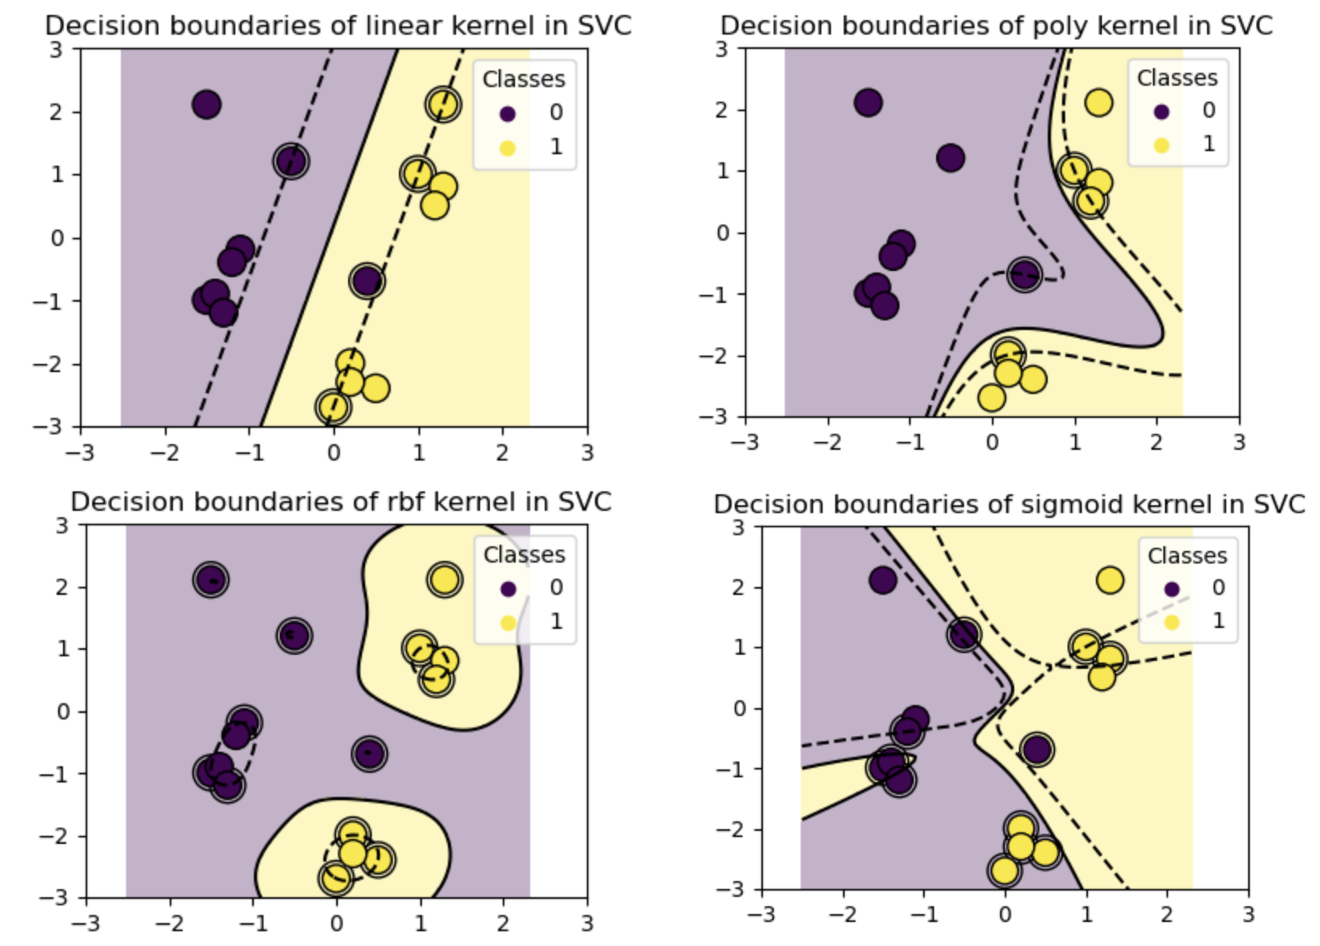

---

#### 💡 **Interprétation des noyaux :**

1. **Noyau Linéaire (en haut à gauche)** :  
   - L'hyperplan est une **ligne droite noire**.  
   - La séparation est **linéaire**, ce qui est adapté aux données **linéairement séparables**.  
   - Utilisé lorsque les classes peuvent être séparées par un **hyperplan linéaire**.  
   - Paramètre **C** : contrôle la **marge et la tolérance aux erreurs** (marge large si faible, plus stricte si élevé).  

2. **Noyau Polynomial (en haut à droite)** :  
   - L'hyperplan est une **courbe noire** représentant une séparation **non linéaire**.  
   - Utile pour capturer des **relations complexes** entre les variables d'entrée.  
   - **Degré** (par exemple, 3) : contrôle la **complexité** de la frontière. Un degré élevé crée une séparation **très sinueuse**.  
   - Paramètre **C** : contrôle la **marge** comme pour les autres noyaux.  

3. **Noyau Gaussien (RBF) (en bas à gauche)** :  
   - La séparation est **flexible**, adaptée aux données avec des **clusters non linéaires**.  
   - L'hyperplan s'adapte à la structure des données, formant des **courbes complexes**.  
   - **Gamma** : contrôle la **portée de l'influence d'un point**.  
     - Un **gamma élevé** crée une séparation **locale et précise**, sensible aux variations (risque de surapprentissage).  
     - Un **gamma faible** produit une séparation **globale et lisse**, capturant une tendance générale.  
   - Paramètre **C** : équilibre entre **marge large** et **erreurs tolérées**.  

4. **Noyau Sigmoïde (en bas à droite)** :  
   - La séparation est **ondulée**, avec des **zones complexes d'interaction**.  
   - Inspiré des **fonctions d'activation** des réseaux neuronaux (forme en "S").  
   - **Gamma** : contrôle la **raideur de la courbe sigmoïde**.  
     - Un **gamma élevé** donne des **transitions abruptes**, créant des frontières **très marquées**.  
     - Un **gamma faible** donne une **courbe plus aplatie**, se rapprochant d'une séparation **linéaire**.  
   - Paramètre **C** : contrôle la **marge** de manière similaire aux autres noyaux.  
   - **Remarque :** Pour des valeurs faibles de gamma, le noyau sigmoïde peut donner des résultats similaires au noyau linéaire.  

---

#### 📝 **Conclusion :**
- Le choix du noyau dépend des **données** et de leur **complexité**.  
- Pour des données linéaires : **Noyau Linéaire**.  
- Pour des interactions polynomiales : **Noyau Polynomial**.  
- Pour des séparations non linéaires complexes : **Noyau Gaussien (RBF)**.  
- Pour des données avec **interactions complexes** ou **inspirées des réseaux neuronaux** : **Noyau Sigmoïde**.  
- Les paramètres **C** et **gamma** jouent un rôle crucial dans le **comportement des modèles** et leur **généralisation**.  


## 4. 💻 Applications pratiques avec scikit-learn

### Classification


Score Linéaire : 0.8500
Score RBF : 0.8750
Score Polynomial : 0.8250
Score Sigmoïde : 0.8500


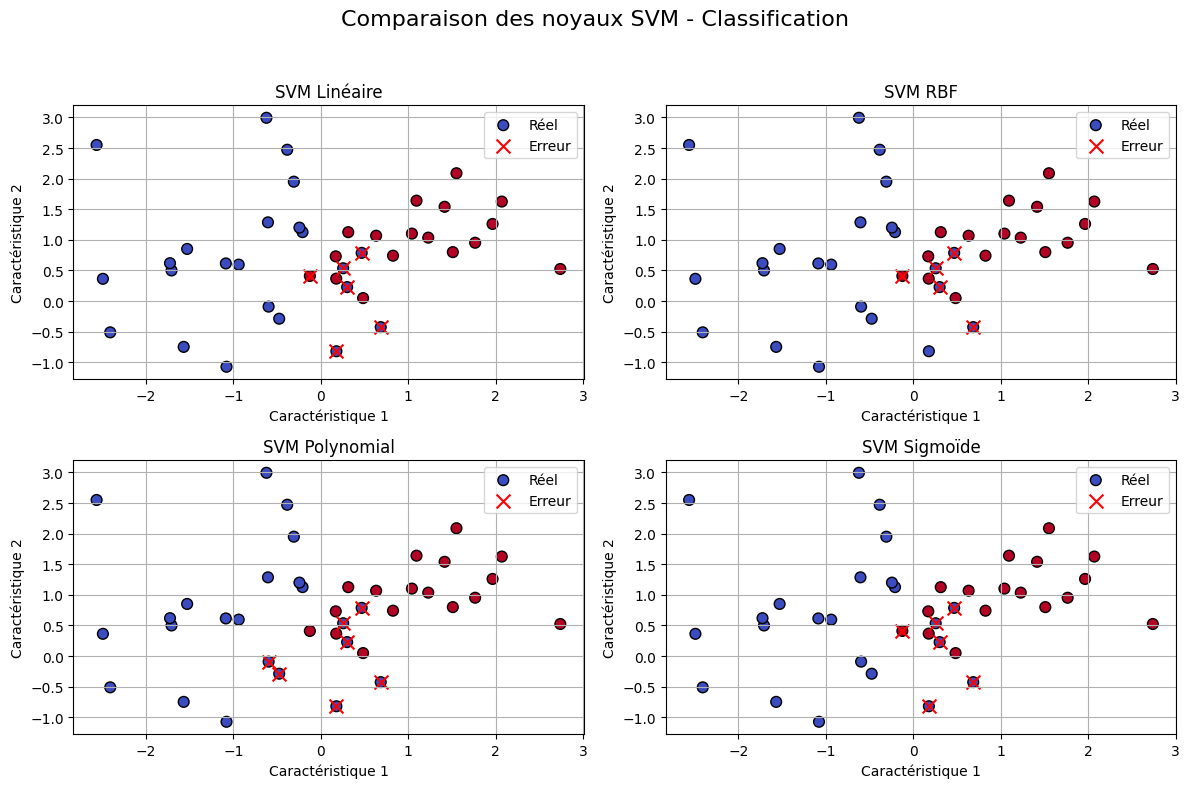

In [5]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 📥 Générer un jeu de données de classification binaire (synthétique)
from sklearn.datasets import make_classification

# 📥 Générer un jeu de données de classification binaire (synthétique)
X, y = make_classification(
    n_samples=200,       # Nombre total d'échantillons à générer
    n_features=2,        # Nombre total de caractéristiques (colonnes) par échantillon = somme de n_informative + n_redundant
    n_informative=2,     # Nombre de caractéristiques réellement informatives pour la classification
    n_redundant=0,       # Nombre de caractéristiques redondantes (combinaisons linéaires des informatives) 2 par défaut
    n_clusters_per_class=1, # Nombre de sous-clusters par classe (1 cluster pour chaque classe ici), 2 par défaut
    random_state=42      # Graine aléatoire pour la reproductibilité des résultats
)


# ✂️ Diviser les données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔧 Initialiser les modèles SVM avec différents noyaux pour la classification
# 🔧 Initialiser les modèles SVM avec différents noyaux pour la classification
models = {
    # Modèle SVM avec noyau linéaire
    # - kernel='linear' : sépare les classes par une droite (hyperplan linéaire).
    # - C=1 : contrôle la pénalisation des erreurs de classification.
    #        - Valeur élevée : marge étroite, moins d'erreurs mais risque de surajustement.
    #        - Valeur faible : marge plus large mais plus d'erreurs tolérées.
    "Linéaire": SVC(kernel='linear', C=1), # C = 1.0 valeur defaut
    
    # Modèle SVM avec noyau RBF (Radial Basis Function)
    # - kernel='rbf' : sépare les classes par une courbe (séparation non linéaire).
    # - gamma=0.1 : contrôle l'influence d'un point d'entraînement.
    #        - Valeur élevée : chaque point a une forte influence (risque de surajustement).
    #        - Valeur faible : la séparation est plus lisse et généralisable.
    # - C=1 : même rôle que précédemment (équilibre entre marge et erreurs).
    "RBF": SVC(kernel='rbf', C=1, gamma=0.1),
    
    # Modèle SVM avec noyau polynomial
    # - kernel='poly' : crée des frontières courbées en utilisant un polynôme.
    # - degree=3 : utilise un polynôme de degré 3 (cubique).
    #        - Degré trop élevé : risque de surajustement.
    # - C=1 : contrôle la marge et les erreurs, comme pour les autres noyaux.
    "Polynomial": SVC(kernel='poly', degree=3, C=1), # degree = 3 valeur par défaut 
    
    # Modèle SVM avec noyau sigmoïde
    # - kernel='sigmoid' : génère une frontière en forme de "S".
    #        - Utilisé principalement pour des modèles de type réseau de neurones.
    # - gamma=0.1 : même rôle que pour le noyau RBF (influence du point).
    # - C=1 : contrôle la marge et la tolérance aux erreurs.
    "Sigmoïde": SVC(kernel='sigmoid', C=1, gamma=0.1)
}

# 🚀 Entraînement et évaluation des modèles
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"Score {name} : {score:.4f}")

# 🎨 Visualisation des résultats pour chaque modèle
plt.figure(figsize=(12, 8))

for i, (name, model) in enumerate(models.items(), 1):
    # Prédiction et erreur
    y_pred = model.predict(X_test)
    errors = (y_pred != y_test)

    # Graphique de classification
    plt.subplot(2, 2, i)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', s=60, label='Réel')
    plt.scatter(X_test[errors, 0], X_test[errors, 1], color='red', marker='x', s=100, label='Erreur')
    plt.title(f"SVM {name}")
    plt.xlabel("Caractéristique 1")
    plt.ylabel("Caractéristique 2")
    plt.legend()
    plt.grid(True)

plt.suptitle("Comparaison des noyaux SVM - Classification", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Interprétation des résultats SVM

### Meilleur noyau : RBF
- Le **noyau RBF** obtient le meilleur score (0.8750) et capture bien la **non-linéarité** des données.
- La séparation est plus **courbée**, avec moins d'erreurs, ce qui montre sa capacité à gérer des **frontières complexes et non linéaires**.
- Ce noyau est particulièrement efficace pour les données présentant des **interactions complexes** entre les variables.

### Noyaux Linéaire et Sigmoïde (mêmes résultats)
- Les modèles **linéaire** et **sigmoïde** donnent des résultats identiques (score de 0.8500) et des graphiques quasi similaires.
- Cela s'explique par le fait que le noyau sigmoïde se comporte ici de manière **quasi linéaire** en raison des paramètres par défaut (gamma faible).
- La frontière de décision est **rectiligne**, adaptée aux données globalement linéaires, ce qui indique que la séparation entre les classes suit une **droite bien définie**.

### Noyau Polynomial
- Le noyau **polynomial** est moins performant (score de 0.8250) et présente une séparation **trop complexe**.
- La frontière est plus **chaotique**, c’est-à-dire que la ligne de séparation est **irrégulière, avec des zigzags ou des courbes abruptes**. Cela traduit une volonté d'épouser au maximum les données d'entraînement, au risque de **surajuster** le modèle.
- Ce comportement indique que le modèle capte le **bruit** des données plutôt que la tendance générale, ce qui le rend moins robuste pour de nouvelles observations.

### Conclusion
- Le modèle **SVM avec noyau RBF** est le plus adapté pour ces données, offrant un bon compromis entre **précision et généralisation**. 
- Les noyaux **linéaire et sigmoïde** donnent des résultats similaires en raison de la nature **plutôt linéaire** des données.
- Le noyau **polynomial** est à éviter ici en raison de son **instabilité** et du risque de *surapprentissage**.


C:\Users\FeiGao\AppData\Local\Temp\ipykernel_19836\2851358027.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\FeiGao\AppData\Local\Temp\ipykernel_19836\2851358027.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\FeiGao\AppData\Local\Temp\ipykernel_19836\2851358027.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


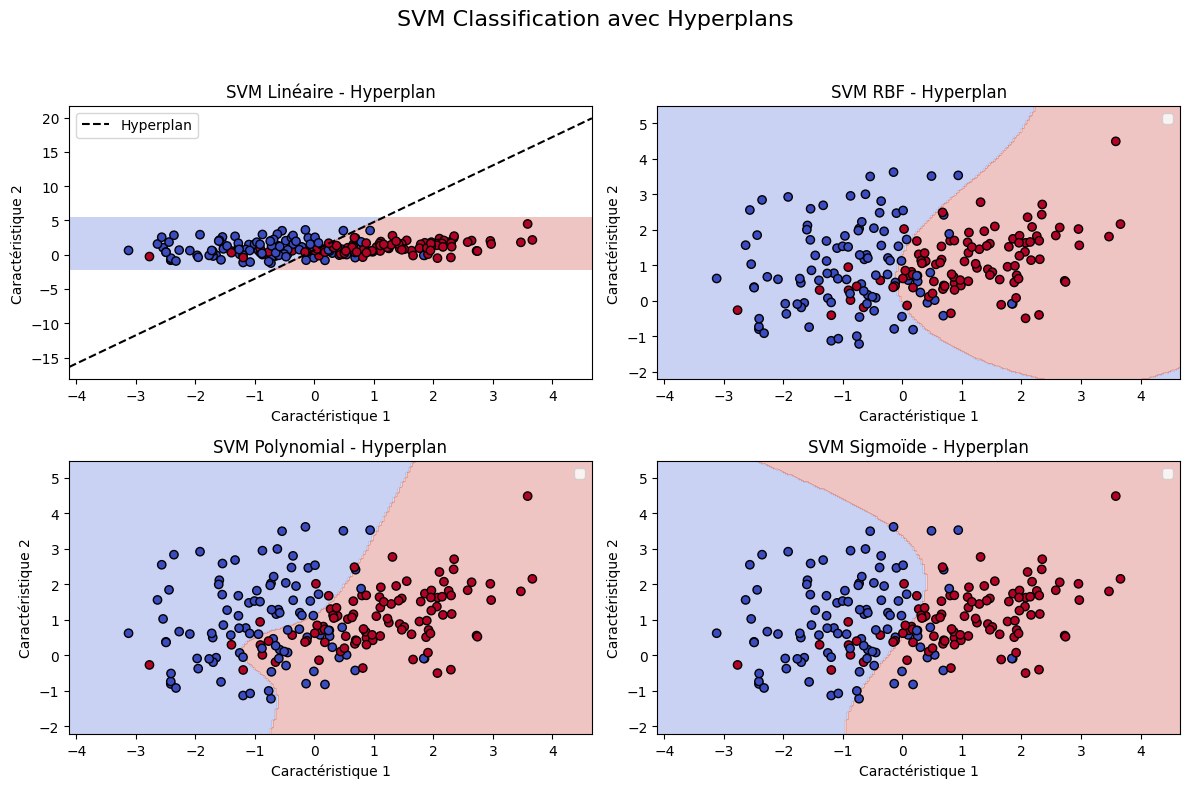

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Génération des données de classification
X, y = make_classification(n_samples=200, n_features=2, 
                           n_informative=2, n_redundant=0, 
                           n_clusters_per_class=1, random_state=42)

# Séparation des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialisation des modèles SVM avec différents noyaux
models = {
    "Linéaire": SVC(kernel='linear', C=1),
    "RBF": SVC(kernel='rbf', C=1, gamma=0.1),
    "Polynomial": SVC(kernel='poly', degree=3, C=1),
    "Sigmoïde": SVC(kernel='sigmoid', C=1, gamma=0.1)
}

plt.figure(figsize=(12, 8))

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train, y_train)

    # Génération de la grille de prédiction
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Tracé du contour de la zone de décision
    plt.subplot(2, 2, i)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Tracé des points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')

    # Tracé de l'hyperplan si noyau linéaire
    if name == "Linéaire":
        w = model.coef_[0]
        a = -w[0] / w[1]
        xx_hyper = np.linspace(x_min, x_max)
        yy_hyper = a * xx_hyper - (model.intercept_[0]) / w[1]
        plt.plot(xx_hyper, yy_hyper, 'k--', label='Hyperplan')

    plt.title(f"SVM {name} - Hyperplan")
    plt.xlabel("Caractéristique 1")
    plt.ylabel("Caractéristique 2")
    plt.legend()

plt.suptitle("SVM Classification avec Hyperplans", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# 📈 Régression par SVM (SVR)

## 📝 Introduction
La régression par machines à vecteurs de support (SVR) est une extension du SVM (Support Vector Machines) utilisée pour les tâches de **régression**.  
Alors que le SVM classique sert à **classer**, le SVR cherche à **prédire une variable continue** en approchant une fonction au plus près des données d'entraînement.

---

## 🎯 Objectif
SVR cherche une fonction de la forme :

$$f(x) = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b$$

Cette fonction doit **prédire** la variable cible $y$ avec la **plus petite erreur possible**, tout en gardant la fonction **simple** (on veut minimiser $||w||^2$).

---

## 📐 La bande de tolérance epsilon ($\varepsilon$)
SVR introduit une **bande de tolérance** (appelée $\varepsilon$) autour de la fonction $f(x)$ :
- Les **points situés à l'intérieur** de cette bande **ne sont pas pénalisés**.
- Les **points situés à l'extérieur** de la bande (au-dessus ou en dessous) sont **considérés c
![Description de l'image](svr_slack_variable.png)omme des erreurs**.

---

## 🔍 Fonction de coût
La fonction à minimiser dans le cadre du SVR est :

$$\frac{1}{2} \sum_{i=1}^{n} w_i^2 + C \sum (\xi_i + \xi_i^*)$$

- $\frac{1}{2} \sum_{i=1}^{n} w_i^2$ : terme de **régularisation** qui pénalise la complexité du modèle.
- $C$ : **coefficient de pénalisation** qui contrôle l’importance donnée aux erreurs.
- $\xi_i$, $\xi_i^*$ : variables de relâche (slack variables), qui mesurent combien un point dépasse la bande de tolérance.

---

## 🖼️ Illustration
Voici une illustration de la SVR. La ligne noire représente la fonction de prédiction $f(x)$, et les lignes pointillées représentent la bande de tolérance $\varepsilon$.  
Les cercles bleus sont les points de données ; ceux en dehors de la bande sont associés à des erreurs ($\xi_i$).

---

## 📊 Interprétation
- La ligne noire $f(x)$ représente la prédiction du modèle.
- Les lignes pointillées délimitent la **zone sans pénalisation** (bande $\varepsilon$).
- Les points **dans la bande** ne sont pas pénalisés.
- Les points **hors de la bande** sont pénalisés via les variables $\xi_i$.

---

## 💡 Pourquoi utiliser SVR ?
- SVR est **robuste aux valeurs aberrantes** grâce à la bande de tolérance.
- Il permet un bon compromis entre la **complexité du modèle** et la **précision de la pré)
plt.xlabel("Variable X")
plt.ylabel("Prédiction")
plt.legend()
plt.show()



### 📝 Phrase concise pour vos étudiants :

Le SVR et la régression linéaire partagent l'objectif de minimiser la complexité du modèle en réduisant $||w||^2$, ce qui permet d'obtenir une fonction de prédiction simple et généralisante.
La différence principale est que le SVR introduit une tolérance aux petites erreurs via la bande $\epsilon$, tandis que la régression linéaire minimise directement l'erreur quadratique moyenne (MSE).

### 📏 Exemple détaillé : prédiction de la taille avec SVR

Supposons que nous cherchions à prédire la **taille** d'une personne en fonction de certaines caractéristiques (par exemple, poids, âge, etc.). Voici deux scénarios :

#### ✅ Estimation correcte (dans la bande de tolérance)

- **Taille réelle** : 1,80 m  
- **Prédiction SVR** : 1,78 m  
- **Erreur absolue** : |1,80 - 1,78| = 0,02 m  
- **Bande de tolérance** : ε = 0,05 m  

👉 Comme l'erreur (0,02 m) est **inférieure** à ε, **aucune pénalisation** n'est appliquée dans la fonction de coût.

#### ❌ Estimation incorrecte (hors de la bande de tolérance)

- **Taille réelle** : 1,80 m  
- **Prédiction SVR** : 1,60 m  
- **Erreur absolue** : |1,80 - 1,60| = 0,20 m  
- **Bande de tolérance** : ε = 0,05 m  

👉 L'erreur (0,20 m) est **supérieure** à ε, donc une **pénalisation** est appliquée.

- **Calcul de la variable de relâche (ξᵢ)** :  
  ξᵢ = |1,80 - 1,60| - ε = 0,20 - 0,05 = 0,15 m  

Cette valeur de ξᵢ est intégrée dans la fonction de coût du SVR :

$$
\frac{1}{2} \|w\|^2 + C \sum (\xi_i + \xi_i^*)
$$

où :
- **C** est le coefficient de pénalisation,
- **ξᵢ** et **ξᵢ\*** sont les variables de relâche pour les erreurs au-dessus et en dessous de la bande de tolérance.

Ainsi, plus l'erreur dépasse ε, plus la pénalisation est importante, ce qui influence l'ajustement du modèle.


### Exercise SVR

🔍 **Pourquoi utiliser `make_friedman1` ?**

- Il génère un jeu de données de **régression non linéaire** avec des **variables indépendantes**.
- Les données suivent la fonction non linéaire suivante :

$$
y = 10 \sin(\pi x_1 x_2) + 20 (x_3 - 0.5)^2 + 10 x_4 + 5 x_5 + \text{bruit}
$$

- Ce jeu de données est utile pour tester des modèles de régression capables de capturer des relations complexes, comme les **SVR avec noyaux non linéaires** (RBF, polynomial, etc.).


In [3]:
from sklearn.svm import SVR
from sklearn.datasets import make_friedman1
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# 📥 Générer un jeu de données de régression non linéaire (synthétique)
X, y = make_friedman1(n_samples=200, random_state=42)

# ✂️ Diviser les données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔧 Initialiser les modèles SVM avec différents noyaux pour la régression
models = {
    "Linéaire": SVR(kernel='linear', C=1),
    "RBF": SVR(kernel='rbf', C=1, gamma=0.1),
    "Polynomial": SVR(kernel='poly', degree=3, C=1),
    "Sigmoïde": SVR(kernel='sigmoid', C=1, gamma=0.1)
}

# 🚀 Entraînement et évaluation des modèles
for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"Score {name} : {score:.4f}")

# 🎨 Visualisation des résultats pour chaque


Score Linéaire : 0.7868
Score RBF : 0.4479
Score Polynomial : 0.7903
Score Sigmoïde : 0.2682


### 📊 **Interprétation des résultats des scores $ R^2$**  

| Noyau       | Scor$( R$\) | Interprétation                                 |
|------------|----------------|-------------------------------------------------|
| Linéaire    | 0.7868         | Bon ajustement pour une relation linéaire         |
| RBF         | 0.4479         | Ajustement moyen pour une relation non linéaire   |
| Polynomial  | 0.7903         | Bon ajustement pour une relation quadratique/cubique |
| Sigmoïde    | 0.2682         | Faible ajustement, transition douce non adaptée   |

---

### 🌟 **Analyse globale :**  

1. **Noyau Linéaire (Score : 0.7868)**  
   - Le modèle explique environ **78.7%** de la variance des données.  
   - Cela indique que la **relation entre les variables est principalement linéaire**.  
   - La régression linéaire est **bien adaptée** pour ce jeu de données.  

2. **Noyau Polynomial (Score : 0.7903)**  
   - Le modèle explique environ **79%** de la variance, très proche du noyau linéaire.  
   - Cela signifie que la **relation n'est pas fondamentalement non linéaire**, mais le noyau polynomial peut **légèrement améliorer** l'ajustement.  
   - Cela peut indiquer que la relation entre les variables contient **quelques interactions quadratiques ou cubiques**.  

3. **Noyau RBF (Score : 0.4479)**  
   - Le modèle n'explique que **44.8%** de la variance.  
   - Le noyau RBF est **trop complexe** pour ce problème, indiquant que la relation est **plutôt linéaire**.  
   - Cela peut également signifier que la **complexité du modèle (surapprentissage)** réduit sa capacité de généralisation.  

4. **Noyau Sigmoïde (Score : 0.2682)**  
   - Le modèle n'explique que **26.8%** de la variance, ce qui est **très faible**.  
   - Le noyau sigmoïde est généralement **moins adapté** aux problèmes de régression et est surtout utilisé pour des **classifications binaires**.  
   - Ici, il produit une **frontière trop complexe** et ne capte pas bien la structure des données.  

---

### ✅ **Conclusion :**  
1. Les scores montrent que le problème est **principalement linéaire**, car les noyaux linéaire et polynomial donnent les **meilleurs résultats**.  
2. Le **noyau RBF**, bien que puissant pour des structures complexes, est ici **trop flexible** et surajuste probablement les données.  
3. Le **noyau sigmoïde** est **clairement inadapté** pour ce jeu de données, comme c'est souvent le cas en régression.  

---

### 🚀 **Recommandation :**  
- Utilisez le **noyau linéaire** comme solution simple et efficace.  
- Si vous suspectez des **relations quadratiques ou cubiques**, vous pouvez essayer le **noyau polynomial**.  
- Évitez les noyaux **RBF** et **sigmoïde** dans ce contexte car ils **surdimensionnent le problème**.  


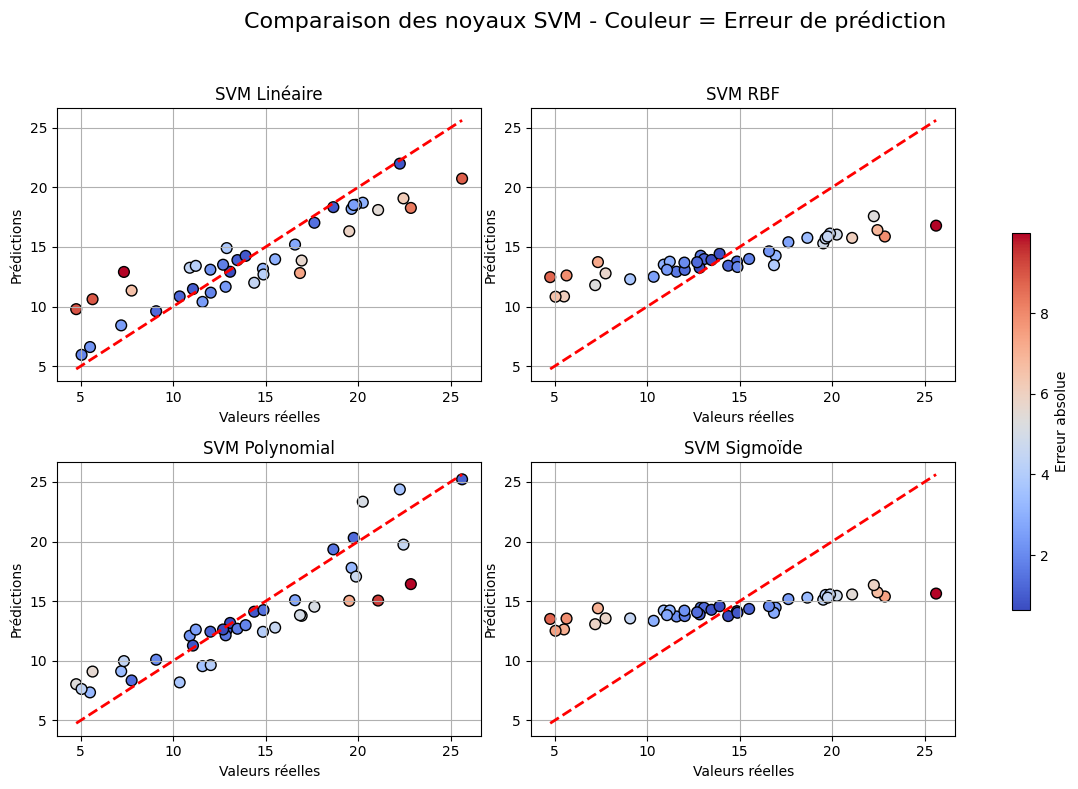

In [4]:
from matplotlib import cm

plt.figure(figsize=(12, 8))

for i, (name, model) in enumerate(models.items(), 1):
    y_pred = model.predict(X_test)
    errors = np.abs(y_pred - y_test)
    
    plt.subplot(2, 2, i)
    sc = plt.scatter(y_test, y_pred, c=errors, cmap='coolwarm', edgecolors='k', s=60)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f"SVM {name}")
    plt.xlabel("Valeurs réelles")
    plt.ylabel("Prédictions")
    plt.grid(True)

plt.suptitle("Comparaison des noyaux SVM - Couleur = Erreur de prédiction", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.colorbar(sc, ax=plt.gcf().get_axes(), label="Erreur absolue", shrink=0.6)
plt.show()


### 💡 Pourquoi les graphes semblent-ils toujours linéaires ?

Lorsque nous utilisons différents noyaux SVM (Linéaire, RBF, Polynomial, Sigmoïde) pour la régression, il peut sembler surprenant que les graphiques de **valeurs réelles vs prédictions** montrent tous une apparente **tendance linéaire**. Voici pourquoi :

#### 📝 Raisons principales :
1. **Représentation des données dans le graphique :**  
   - Ces graphiques montrent les **valeurs réelles (axe X)** par rapport aux **valeurs prédites (axe Y)**.  
   - Si le modèle est performant, les points doivent être **alignés autour de la diagonale** (ligne rouge), indiquant que les prédictions correspondent aux valeurs réelles, **même si la relation dans l'espace des caractéristiques n'est pas linéaire**.

2. **Nature des données générées par `make_friedman1` :**  
   - Ce jeu de données présente des relations **non linéaires**, mais avec une **forte corrélation globale** entre certaines variables (`x1`, `x2`) et la variable cible.  
   - La **relation globale reste monotone**, ce qui explique pourquoi même les modèles non linéaires montrent une tendance proche de la linéarité dans le graphique des prédictions.

3. **Erreur d'interprétation courante :**  
   - Les noyaux **RBF**, **Polynôme** et **Sigmoïde** introduisent de la **non-linéarité dans l’espace des caractéristiques**, pas forcément dans la **sortie prédite**.  
   - Ce que nous observons ici est une **relation prédiction-réalité**, pas la structure interne du modèle.

---

### 🌟 Visualisation alternative pour mieux comprendre :
Pour mieux saisir la non-linéarité apportée par chaque noyau, il est plus pertinent de tracer les **prédictions en fonction de l'une des variables d'entrée**.  
Cela permet de voir l'impact du noyau directement sur les prédictions en fonction d'une variable spécifique (par exemple, `X1`).  

#### 🖼️ Représentation attendue :
- **Linéaire :** Une droite si les données sont bien alignées.  
- **RBF :** Une courbe avec des variations complexes, illustrant la **flexibilité du noyau**.  
- **Polynôme :** Une courbe d'ordre supérieur (quadratique ou cubique), montrant la **capacité à capturer des relations polynomiales**.  
- **Sigmoïde :** Une courbe en "S" ou aplatie, montrant un **comportement de classification binaire** qui est parfois mal adapté à la régression.  

➡️ **Conseil pratique :** Pour visualiser cela, il suffit de tracer les **prédictions** et les **valeurs réelles** par rapport à une variable explicative choisie, en utilisant des couleurs pour distinguer les deux.  
